In [ ]:
"""
肺癌患者性别分组生存分析

基于经典的lung肺癌患者数据集
采用非参数方法对比男性和女性患者的生存差异，核心围绕Kaplan-Meier生存估计、Nelson-Aalen风险估计和Log-Rank组间差异检验展开
"""

In [1]:
# 模块 1：环境准备与数据加载
"""
pandas/numpy：负责数据读取、预处理和数值操作；
matplotlib.pyplot：负责所有分析结果的可视化；
KaplanMeierFitter：Kaplan-Meier（KM）生存分析的核心拟合工具，用于估计生存函数。

数据加载：读取lung.csv数据集（该数据集是lifelines内置经典数据集，包含肺癌患者的生存时间、结局状态、性别等关键信息），data.head()用于快速预览前 5 行数据，验证数据是否成功加载及数据结构是否符合预期。
"""
# 导入所需库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 读取数据集
data = pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验十二/lung.csv")
data.head()

,Unnamed: 0,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,1,3.0,306,2,74,1,1.0,90.0,100.0,1175.0,NaN
1,2,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0
2,3,3.0,1010,1,56,1,0.0,90.0,90.0,NaN,15.0
3,4,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0
4,5,1.0,883,2,60,1,0.0,100.0,90.0,NaN,0.0


In [2]:
# 模块 2：数据预处理（结局状态变量重构）

"""
这是生存分析的关键预处理步骤，核心是统一事件状态的标记规则：

原数据status字段定义：
    status=1：截尾数据（Censored），即患者未发生「死亡」事件（如失访、研究结束时仍存活）；
    status=2：事件发生，即患者在研究期间死亡。

生存分析标准标记规则：
    用0表示「截尾」（未发生目标事件）；
    用1表示「事件发生」（发生目标事件，此处为死亡）。
操作结果：新建dead字段，完成状态转换，为后续模型拟合提供符合要求的事件标记数据。
"""

# 重构事件状态变量：将原status转换为标准生存分析事件标记
data.loc[data.status == 1, 'dead'] = 0
data.loc[data.status == 2, 'dead'] = 1
data.head()

,Unnamed: 0,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss,dead
0,1,3.0,306,2,74,1,1.0,90.0,100.0,1175.0,NaN,1.0
1,2,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0,1.0
2,3,3.0,1010,1,56,1,0.0,90.0,90.0,NaN,15.0,0.0
3,4,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0,1.0
4,5,1.0,883,2,60,1,0.0,100.0,90.0,NaN,0.0,1.0


In [4]:
# 模块 3：数据分组与 KM 模型初始化

"""
KM 模型初始化：创建两个独立的KaplanMeierFitter实例，避免分组拟合时互相干扰，分别用于男性（kmf_m）和女性（kmf_f）患者的生存函数估计。
分组操作：通过pandas.query()方法按sex字段拆分数据集，实现男女组的独立分析，后续所有分析均基于分组数据展开，核心目的是对比两组差异。
分组预览：验证分组是否正确，确保无数据遗漏或错分。
"""

# 初始化两个KM拟合实例，分别对应男女组
kmf_m = KaplanMeierFitter()
kmf_f = KaplanMeierFitter()

# 按性别拆分数据：sex=1为男性，sex=2为女性
Male = data.query("sex == 1")
Female = data.query("sex == 2")

# 预览分组数据
print("male:")
print(Male.head())

print("female:")
print(Female.head())

male:
   Unnamed: 0  inst  time  status  age  sex  ph.ecog  ph.karno  pat.karno  \
0           1   3.0   306       2   74    1      1.0      90.0      100.0   
1           2   3.0   455       2   68    1      0.0      90.0       90.0   
2           3   3.0  1010       1   56    1      0.0      90.0       90.0   
3           4   5.0   210       2   57    1      1.0      90.0       60.0   
4           5   1.0   883       2   60    1      0.0     100.0       90.0   

   meal.cal  wt.loss  dead  
0    1175.0      NaN   1.0  
1    1225.0     15.0   1.0  
2       NaN     15.0   0.0  
3    1150.0     11.0   1.0  
4       NaN      0.0   1.0  
female:
    Unnamed: 0  inst  time  status  age  sex  ph.ecog  ph.karno  pat.karno  \
6            7   7.0   310       2   68    2      2.0      70.0       60.0   
7            8  11.0   361       2   71    2      2.0      60.0       80.0   
11          12  16.0   654       2   68    2      2.0      70.0       70.0   
12          13  11.0   728       2   

In [6]:
# 模块 4：Kaplan-Meier（KM）模型拟合与核心指标提取

"""
这是 KM 生存分析的核心步骤，fit()方法的三个关键参数：
    durations：生存时间（持续时间），即患者从入组到「死亡事件」或「截尾」的时间（对应time列）；
    event_observed：事件是否发生的标记（对应dead列），用于处理截尾数据；
    label：分组标签，用于后续可视化和结果区分。
"""
# 拟合KM模型
kmf_m.fit(durations =  Male["time"],event_observed = Male["dead"] ,label="Male")
kmf_f.fit(durations =  Female["time"],event_observed = Female["dead"], label="Female")

<lifelines.KaplanMeierFitter:"Female", fitted with 90 total observations, 37 right-censored observations>

In [8]:
"""
后续提取的一系列 KM 核心指标，均基于此次拟合结果：
"""

# ·事件表（event_table）：每个时间点的患者存活数、事件发生数、截尾数等底层数据，是 KM 生存估计的计算依据；
#Event table for male group:
kmf_m.event_table

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,138,138
11.0,3,3,0,0,138
12.0,1,1,0,0,135
13.0,2,2,0,0,134
15.0,1,1,0,0,132
...,...,...,...,...,...
814.0,1,1,0,0,5
840.0,1,0,1,0,4
883.0,1,1,0,0,3


In [9]:
#Event table for female group:
kmf_f.event_table

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,90,90
5.0,1,1,0,0,90
60.0,1,1,0,0,89
61.0,1,1,0,0,88
62.0,1,1,0,0,87
...,...,...,...,...,...
735.0,1,1,0,0,5
740.0,1,0,1,0,4
765.0,1,1,0,0,3


In [11]:
# ·单点生存概率预测（predict(11)）：估计患者在第 11 天仍存活的概率，predict(t)可输出任意时间t的生存概率；
#Predict value based on time:
print("male:", kmf_m.predict(11))

#Predict value based on time:
print("female:", kmf_f.predict(11))

male: 0.9782608695652172
female: 0.9888888888888887


In [12]:
# ·生存函数（survival_function_）：提取完整的 KM 生存函数S(t)数据，S(t)表示「患者存活时间超过t的概率」，是生存分析的核心指标，取值范围 [0,1]，随时间推移单调不递增；
#Get complete data of survival function for male group:
kmf_m.survival_function_

,Male
timeline,
0.0,1.000000
11.0,0.978261
12.0,0.971014
13.0,0.956522
15.0,0.949275
...,...
814.0,0.053571
840.0,0.053571
883.0,0.035714


In [13]:
#Get complete data of survival function for female group:
kmf_f.survival_function_

,Female
timeline,
0.0,1.000000
5.0,0.988889
60.0,0.977778
61.0,0.966667
62.0,0.955556
...,...
735.0,0.124822
740.0,0.124822
765.0,0.083214


Text(0.5, 1.0, 'KMF')

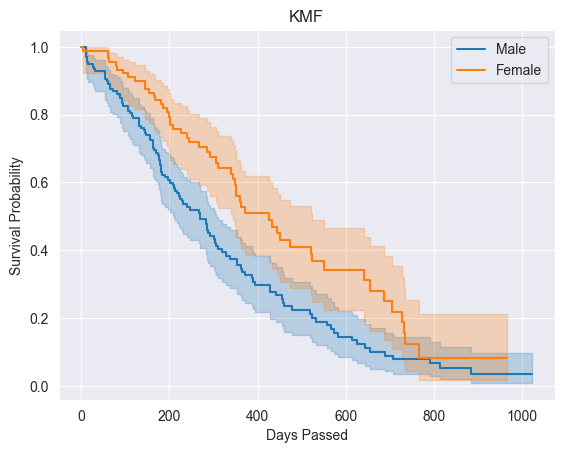

In [14]:
#Plot the survival_function data:
kmf_m.plot()
kmf_f.plot()
plt.xlabel("Days Passed")
plt.ylabel("Survival Probability")
plt.title("KMF")

In [15]:
# ·累积密度（cumulative_density_）：即1 - S(t)，表示「患者在时间t及之前发生死亡事件的概率」，反映事件发生的累积概率；

#Cumulative density for male group:
kmf_m.cumulative_density_

,Male
timeline,
0.0,0.000000
11.0,0.021739
12.0,0.028986
13.0,0.043478
15.0,0.050725
...,...
814.0,0.946429
840.0,0.946429
883.0,0.964286


In [16]:
#Cumulative density for female group:
kmf_f.cumulative_density_

,Female
timeline,
0.0,0.000000
5.0,0.011111
60.0,0.022222
61.0,0.033333
62.0,0.044444
...,...
735.0,0.875178
740.0,0.875178
765.0,0.916786


Text(0, 0.5, 'Probability')

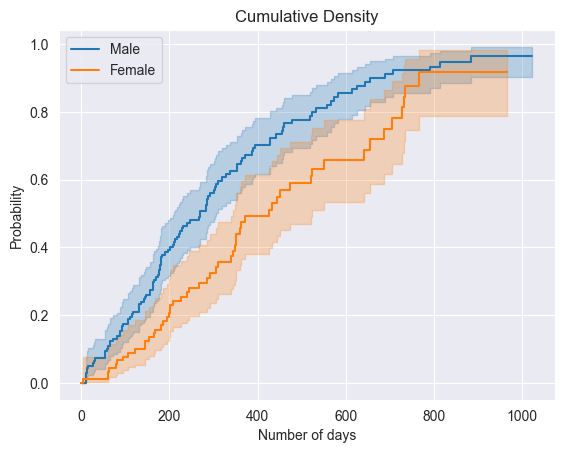

In [17]:
#PLot the graph for cumulative density for both groups:
kmf_m.plot_cumulative_density()
kmf_f.plot_cumulative_density()
plt.title("Cumulative Density")
plt.xlabel("Number of days")
plt.ylabel("Probability")

In [18]:
# 模块 6：Nelson-Aalen（NA）累积风险分析
"""
核心目的：NA 法是另一种非参数方法，专门用于估计累积风险函数H(t)，风险函数表示「患者在某个时间点发生死亡事件的瞬时速率」，累积风险是其在时间t内的累积值；
拟合与指标提取：与 KM 拟合逻辑一致，传入生存时间和事件标记，后续提取cumulative_hazard_（累积风险数据）并通过plot_cumulative_hazard()可视化，直观对比男女组的累积风险趋势（H(t)通常随时间递增，事件发生越多，累积风险越高）；
联合可视化：将 KM 累积密度和 NA 累积风险绘制在同一图中，验证同一分组的指标趋势一致性，进一步支撑分析结果的可靠性。
"""
#Hazard Function:
from lifelines import NelsonAalenFitter

#Fitting the data into objects:
naf_m = NelsonAalenFitter()
naf_f = NelsonAalenFitter()
naf_m.fit(Male["time"],event_observed = Male["dead"])
naf_f.fit(Female["time"],event_observed = Female["dead"])

#Cumulative hazard for male group:
naf_m.cumulative_hazard_

,NA_estimate
timeline,
0.0,0.000000
11.0,0.021899
12.0,0.029306
13.0,0.044287
15.0,0.051863
...,...
814.0,2.831337
840.0,2.831337
883.0,3.164670


In [19]:
#Cumulative hazard for female group:
naf_f.cumulative_hazard_

,NA_estimate
timeline,
0.0,0.000000
5.0,0.011111
60.0,0.022347
61.0,0.033711
62.0,0.045205
...,...
735.0,1.988977
740.0,1.988977
765.0,2.322310


Text(0, 0.5, 'Cumulative Hazard')

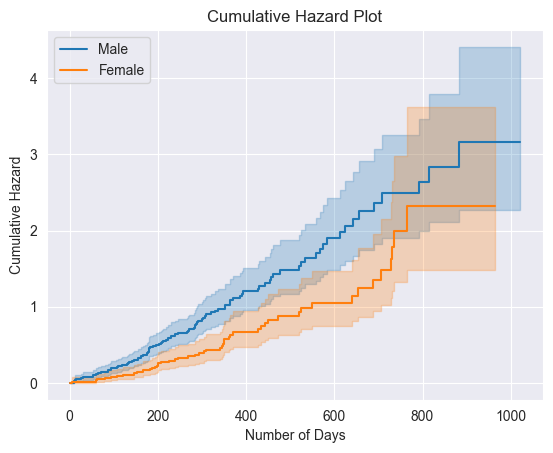

In [20]:
#Plot the graph for cumulative hazard:
naf_m.plot_cumulative_hazard(label="Male")
naf_f.plot_cumulative_hazard(label="Female")
plt.title("Cumulative Hazard Plot")
plt.xlabel("Number of Days")
plt.ylabel("Cumulative Hazard")

In [23]:
# ·条件中位生存时间（conditional_time_to_event_）：表示「患者已经存活到时间t的前提下，剩余的中位生存时间」，反映存活者的后续生存预期；
#Conditional median time to event of interest:
kmf_m.conditional_time_to_event_

,Male - Conditional median duration remaining to event
timeline,
0.0,270.0
11.0,272.0
12.0,271.0
13.0,271.0
15.0,270.0
...,...
814.0,inf
840.0,inf
883.0,inf


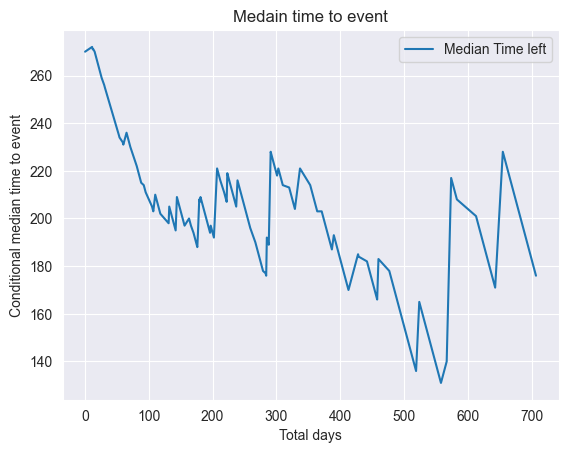

In [24]:
#Conditional median time left for event for male group:
median_time_to_event = kmf_m.conditional_time_to_event_
plt.plot(median_time_to_event,label="Median Time left")
plt.title("Medain time to event")
plt.xlabel("Total days")
plt.ylabel("Conditional median time to event")
plt.legend()

In [25]:
#Conditional median time to event of interest for female group:
kmf_f.conditional_time_to_event_

,Female - Conditional median duration remaining to event
timeline,
0.0,426.0
5.0,421.0
60.0,373.0
61.0,372.0
62.0,371.0
...,...
735.0,inf
740.0,inf
765.0,inf


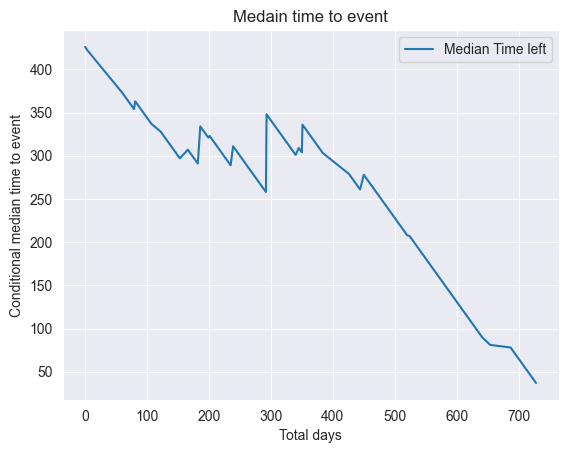

In [26]:
#Conditional median time left for event for female group:
median_time_to_event = kmf_f.conditional_time_to_event_
plt.plot(median_time_to_event,label="Median Time left")
plt.title("Medain time to event")
plt.xlabel("Total days")
plt.ylabel("Conditional median time to event")
plt.legend()

In [27]:
# ·生存函数置信区间（confidence_interval_survival_function_）：提取默认 95% 置信区间的上下限数据，反映 KM 生存估计的不确定性（置信区间越窄，估计结果越可靠）。
#Survival probability with confidence interval for male group:
kmf_m.confidence_interval_survival_function_

,Male_lower_0.95,Male_upper_0.95
0.0,1.000000,1.000000
11.0,0.934122,0.992937
12.0,0.924619,0.989022
13.0,0.905787,0.980229
15.0,0.896549,0.975490
...,...,...
814.0,0.019335,0.114081
840.0,0.019335,0.114081
883.0,0.008603,0.096828
1010.0,0.008603,0.096828


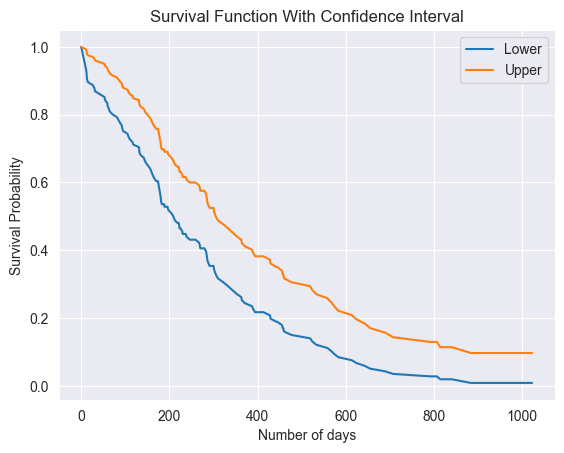

In [28]:
#Plot survival function with confidence interval for male group:
confidence_surv_func = kmf_m.confidence_interval_survival_function_
plt.plot(confidence_surv_func["Male_lower_0.95"],label="Lower")
plt.plot(confidence_surv_func["Male_upper_0.95"],label="Upper")
plt.title("Survival Function With Confidence Interval")
plt.xlabel("Number of days")
plt.ylabel("Survival Probability")
plt.legend()

In [29]:
#Survival probability with confidence interval for female group:
kmf_f.confidence_interval_survival_function_

,Female_lower_0.95,Female_upper_0.95
0.0,1.000000,1.000000
5.0,0.923743,0.998427
60.0,0.914060,0.994396
61.0,0.900217,0.989126
62.0,0.885909,0.983083
...,...,...
735.0,0.042931,0.252736
740.0,0.042931,0.252736
765.0,0.018505,0.212364
821.0,0.018505,0.212364


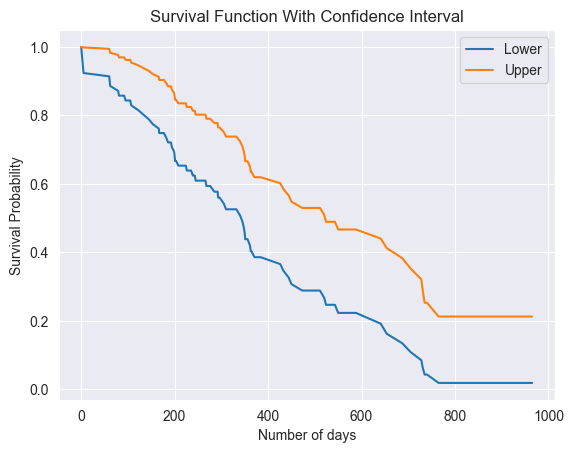

In [30]:
#Plot survival function with confidence interval for female group:
confidence_surv_func = kmf_f.confidence_interval_survival_function_
plt.plot(confidence_surv_func["Female_lower_0.95"],label="Lower")
plt.plot(confidence_surv_func["Female_upper_0.95"],label="Upper")
plt.title("Survival Function With Confidence Interval")
plt.xlabel("Number of days")
plt.ylabel("Survival Probability")
plt.legend()

Text(0.5, 0, 'Number of Days')

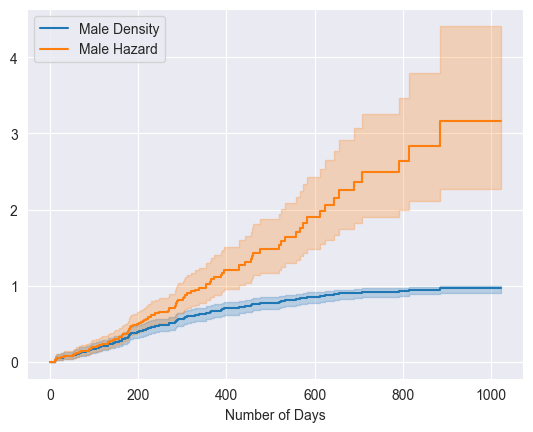

In [31]:
#Plot the cumulative_hazard and cumulative density:
kmf_m.plot_cumulative_density(label="Male Density")
naf_m.plot_cumulative_hazard(label="Male Hazard")
plt.xlabel("Number of Days")

Text(0.5, 0, 'Number of Days')

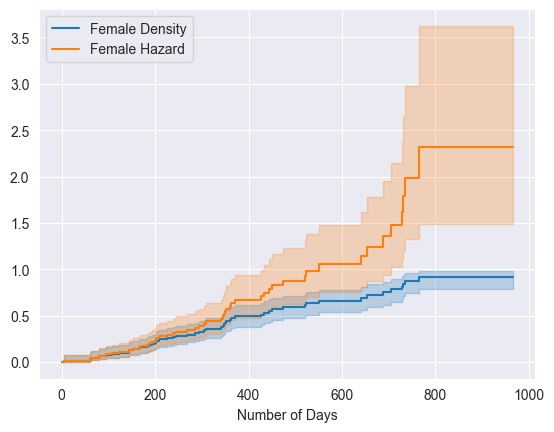

In [32]:
#Plot the cumulative_hazard and cumulative density:
kmf_f.plot_cumulative_density(label="Female Density")
naf_f.plot_cumulative_hazard(label="Female Hazard")
plt.xlabel("Number of Days")

In [34]:
# 模块 7：Log-Rank 检验（组间生存差异统计验证）

"""
检验目的：Log-Rank 检验是生存分析中用于比较两组或多组生存曲线是否存在显著统计学差异的非参数检验，解决「可视化观察到的差异是否具有统计学意义」的问题；
检验假设：
原假设（H0）：两组生存曲线无差异，男女肺癌患者的生存规律一致；
备择假设（H1）：两组生存曲线存在差异，男女肺癌患者的生存规律不一致；
结果解读：
results.print_summary()：打印详细检验结果，包括检验统计量、p 值、95% 置信区间等；
p 值：核心判断指标，通常以p < 0.05为差异具有统计学意义的标准；若 p 值 < 0.05，拒绝原假设，说明男女组生存差异显著；若 p 值≥0.05，无法拒绝原假设，说明两组生存差异无统计学意义。
"""
# 导入Log-Rank检验工具
from lifelines.statistics import logrank_test

# 准备分组数据
Time_A = Male['time']
Event_A = Male['dead']
Time_B = Female['time']
Event_B = Female['dead']

# 执行Log-Rank检验
results = logrank_test(Time_A, Time_B, event_observed_A=Event_A, event_observed_B=Event_B)
results.print_summary()

# 打印p值
print("P-value :",results.p_value)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          10.33 <0.005      9.57

P-value : 0.0013111645203554838
